In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib import cm
from tqdm import tqdm
import os
import torch
torch.cuda.empty_cache()
np.random.seed(123)
torch.manual_seed(200)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(200)
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
from numpy import linalg as la
from numpy import *
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
# from solver_sdmd_torch_gpu import KoopmanNNTorch, KoopmanSolverTorch


print (torch.__version__, torch.cuda.is_available())
print(torch.version.cuda)
print (torch.cuda.get_device_name())
# device= 'cpu'
device= 'cuda'

2.3.1 True
11.8
NVIDIA GeForce RTX 3070 Ti


In [2]:
torch.cuda.empty_cache()

In [3]:
#### Test 2 ####
## Define the potential function V(x, y) and plot the potential landscape
def potential(x, y):
    return (
        3 * np.exp(-x**2 - (y - 1/3)**2)
        - 3 * np.exp(-x**2 - (y - 5/3)**2)
        - 5 * np.exp(-(x - 1)**2 - y**2)
        - 5 * np.exp(-(x + 1)**2 - y**2)
        + 0.2 * x**4
        + 0.2 * (y - 1/3)**4
    )

# Define the gradient of the potential function
def gradient(x, y):
    dVdx = (
        -6 * x * np.exp(-x**2 - (y - 1/3)**2)
        + 6 * x * np.exp(-x**2 - (y - 5/3)**2)
        + 10 * (x - 1) * np.exp(-(x - 1)**2 - y**2)
        + 10 * (x + 1) * np.exp(-(x + 1)**2 - y**2)
        + 0.8 * x**3
    )
    dVdy = (
        -6 * (y - 1/3) * np.exp(-x**2 - (y - 1/3)**2)
        + 6 * (y - 5/3) * np.exp(-x**2 - (y - 5/3)**2)
        + 10 * y * np.exp(-(x - 1)**2 - y**2)
        + 10 * y * np.exp(-(x + 1)**2 - y**2)
        + 0.8 * (y - 1/3)**3
    )
    return dVdx, dVdy

## Generate m^2 trajectories in the landscape
# Set the parameters for the SDE
#h = 1e-3  # Integration step size
h = 1e-3  # Integration step size
#h = 1e-5  # Integration step size
n_steps = 100  # Number of integration steps between each evaluation
n_eval = 10  # Number of evaluations
lag_time = h * n_steps  # Lag time

# Set the number of points to select in each dimension
m = 35

# Set the diffusion coefficient
sigma = 1.09
print ('Lag time: ', lag_time)



# Generate linspace for x and y coordinates
x_values = np.linspace(-2, 2, m)
y_values = np.linspace(-1, 2, m)

# Create a meshgrid from these linspace arrays
xx, yy = np.meshgrid(x_values, y_values)

# Flatten the meshgrid matrices to get the coordinate pairs
x0_values = xx.flatten()
y0_values = yy.flatten()

# Initialize the data_matrix
data_matrix = np.zeros((m**2, n_eval+1, 2))

# Generate trajectories for each selected point
for i in tqdm (range(m**2)):
    x = x0_values[i]
    y = y0_values[i]
    
    for j in range(n_eval+1):
        data_matrix[i, j, 0] = x
        data_matrix[i, j, 1] = y
        
        for k in range(n_steps):
            dVdx, dVdy = gradient(x, y)
            x += -dVdx * h + sigma * np.sqrt(h) * np.random.normal()
            y += -dVdy * h + sigma * np.sqrt(h) * np.random.normal()

# Create a grid of points
x_plot = np.linspace(-2, 2, 100)
y_plot = np.linspace(-1, 2, 100)
X, Y = np.meshgrid(x_plot, y_plot)



# Extract data_X and data_Y from the data matrix
data_X = data_matrix[:, :-1, :]
data_Y = data_matrix[:, 1:, :]
print(f"Shape of data_X: {data_X.shape}")
print(f"Shape of data_Y: {data_Y.shape}")

# Reshape data_X and data_Y into a single column
X = data_X.reshape(-1, data_X.shape[2])  # 2D features
Y = data_Y.reshape(-1, data_X.shape[2])  # 2D targets
print(f"Shape of X: {X.shape}")
print(f"Shape of Y: {Y.shape}")

# Separate data into two parts: train and validation
len_all = X.shape[0]
data_x_train = X[:int(0.7*len_all)]
data_x_valid = X[int(0.7*len_all)+1:]

data_y_train = Y[:int(0.7*len_all)]
data_y_valid = Y[int(0.7*len_all)+1:]

data_train = [data_x_train, data_y_train]
data_valid = [data_x_valid, data_y_valid]

print(data_x_train.shape)


Lag time:  0.1


  0%|          | 0/1225 [00:00<?, ?it/s]

  1%|          | 8/1225 [00:00<00:16, 73.79it/s]

  1%|▏         | 16/1225 [00:00<00:16, 73.49it/s]

  2%|▏         | 24/1225 [00:00<00:16, 73.83it/s]

...

 98%|█████████▊| 1202/1225 [00:16<00:00, 74.57it/s]

 99%|█████████▉| 1210/1225 [00:16<00:00, 74.37it/s]

 99%|█████████▉| 1218/1225 [00:16<00:00, 74.73it/s]

100%|██████████| 1225/1225 [00:17<00:00, 71.66it/s]

Shape of data_X: (1225, 10, 2)
Shape of data_Y: (1225, 10, 2)
Shape of X: (12250, 2)
Shape of Y: (12250, 2)
(8575, 2)


In [4]:
from solver_edmd_torch_gpu import KoopmanNNTorch, EDMDSolverTorch
#### EDMD Test ####
checkpoint_file= 'well2d_example_ckpt001_e.torch'

basis_function = KoopmanNNTorch(input_size= 2, layer_sizes=[20, 20], n_psi_train=12).to(device)

solver = EDMDSolverTorch(
    dic=basis_function,
    target_dim=np.shape(data_x_train)[-1],
    reg=0.1,
    checkpoint_file=checkpoint_file,
    batch_size=32
)

data_x_train_tensor = torch.DoubleTensor(data_x_train).to (device)#, requieres_grad= True)#, dtype=tf.float64)
data_y_train_tensor = torch.DoubleTensor(data_y_train).to (device)#, requires_grad= True)#, dtype=tf.float64)

solver.build_with_edmd(
    data_train=data_train,
    data_valid=data_valid,
    epochs=6,
    batch_size=256,
    lr=1e-5,
    log_interval=10,
    lr_decay_factor=0.8
)

# Results from solver_edmd
evalues = solver.eigenvalues.T
efuns = solver.eigenfunctions(X)
N_dict = np.shape(evalues)[0]
Koopman_matrix_K = solver.K
outputs = {
    'efuns': efuns,
    'evalues': evalues,
    'N_dict': N_dict,
    # 'K': Koopman_matrix_K
    }


Outer Epoch 1/6


Epoch: 1 	Training Loss: 0.010974 val loss: 0.014239
saving, val loss enhanced: 0.014239372693089948 1000000000000000.0
Epoch: 2 	Training Loss: 0.010962 val loss: 0.014227
saving, val loss enhanced: 0.014227133422847007 0.014239372693089948


Epoch: 3 	Training Loss: 0.010953 val loss: 0.014229
Outer Epoch 2/6
Epoch: 1 	Training Loss: 0.010944 val loss: 0.014210
saving, val loss enhanced: 0.014209621889446869 0.014227133422847007


Epoch: 2 	Training Loss: 0.010934 val loss: 0.014209
saving, val loss enhanced: 0.014208832143365416 0.014209621889446869


Epoch: 3 	Training Loss: 0.010924 val loss: 0.014192
saving, val loss enhanced: 0.014192415768940848 0.014208832143365416
Outer Epoch 3/6
Epoch: 1 	Training Loss: 0.010916 val loss: 0.014181
saving, val loss enhanced: 0.01418114839999639 0.014192415768940848


...

Epoch: 3 	Training Loss: 0.010868 val loss: 0.014145
saving, val loss enhanced: 0.014144500054794772 0.014146182670274236
Outer Epoch 5/6
Epoch: 1 	Training Loss: 0.010859 val loss: 0.014120
saving, val loss enhanced: 0.014120173228810456 0.014144500054794772


Epoch: 2 	Training Loss: 0.010849 val loss: 0.014121


Epoch: 3 	Training Loss: 0.010841 val loss: 0.014116
saving, val loss enhanced: 0.014115726601603812 0.014120173228810456
Outer Epoch 6/6


Epoch: 1 	Training Loss: 0.010832 val loss: 0.014105
saving, val loss enhanced: 0.014104782646444828 0.014115726601603812
Epoch: 2 	Training Loss: 0.010821 val loss: 0.014092
saving, val loss enhanced: 0.01409203749407041 0.014104782646444828


Epoch: 3 	Training Loss: 0.010813 val loss: 0.014087
saving, val loss enhanced: 0.014086545050731761 0.01409203749407041


(15,)
[1.000e+00+0.j     9.936e-01+0.j     8.812e-01+0.j     5.428e-01-0.0103j
 5.428e-01+0.0103j 3.384e-01-0.0057j 3.384e-01+0.0057j 3.092e-01+0.j
 2.719e-01+0.j     8.960e-02+0.j     1.590e-02+0.j     7.500e-03+0.j
 3.400e-03+0.j     1.500e-03+0.j     6.000e-04+0.j    ]


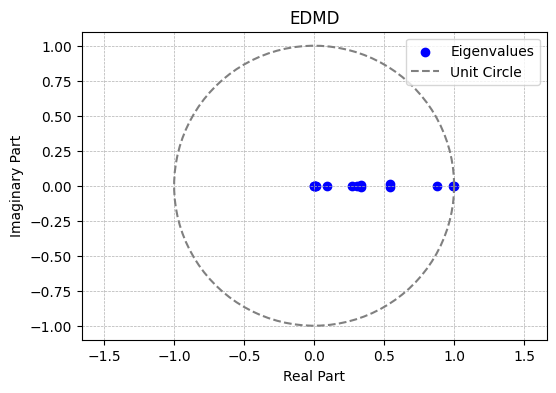

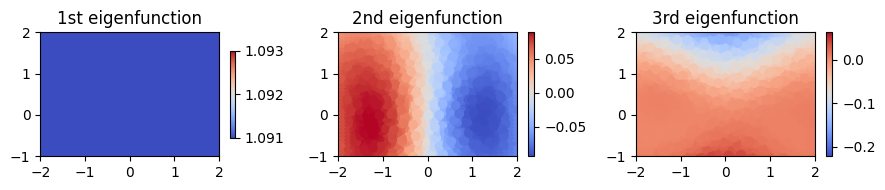

In [5]:
# Assuming 'efuns' is a 2D numpy array with shape (n_samples, n_eigenfunctions)
# and 'X' is a 2D numpy array with shape (n_samples, 2) representing your input data

# Assuming evalues is a numpy array of complex numbers
print(evalues.shape)
print(np.round(evalues, 4))

# Plot eigenvalues on unit circle
real_parts = evalues.real
imag_parts = evalues.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('EDMD')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

# Plot eigenfunctions
fig, axs = plt.subplots(1, 3, figsize=(9, 2))

# Plot for the 1st eigenfunction
# scatter1 = axs[0].scatter(*X.T, c=np.real(efuns)[:, 0], cmap='coolwarm')
scatter1 = axs[0].scatter(*X.T, c=np.real(efuns)[:, 0], cmap='coolwarm', vmin=1.091, vmax=1.093)
axs[0].set_title('1st eigenfunction')
axs[0].set_xlim(-2, 2)
axs[0].set_ylim(-1, 2)
cbar1 = fig.colorbar(scatter1, ax=axs[0], shrink=0.7, aspect=20)

# Plot for the 2nd eigenfunction
scatter2 = axs[1].scatter(*X.T, c=np.real(efuns)[:, 1], cmap='coolwarm')
axs[1].set_title('2nd eigenfunction')
axs[1].set_xlim(-2, 2)
axs[1].set_ylim(-1, 2)
cbar2 = fig.colorbar(scatter2, ax=axs[1])

# Plot for the 3rd eigenfunction
scatter3 = axs[2].scatter(*X.T, c=np.real(efuns)[:, 2], cmap='coolwarm')
axs[2].set_title('3rd eigenfunction')
axs[2].set_xlim(-2, 2)
axs[2].set_ylim(-1, 2)
cbar3 = fig.colorbar(scatter3, ax=axs[2])

# # Plot for the 4th eigenfunction
# scatter4 = axs[3].scatter(*X.T, c=np.real(efuns)[:, 3], cmap='coolwarm')
# axs[3].set_title('4th eigenfunction')
# axs[3].set_xlim(-2, 2)
# axs[3].set_ylim(-1, 2)
# cbar4 = fig.colorbar(scatter4, ax=axs[3])

# fig.suptitle(' SDMD ', fontsize=16)
plt.tight_layout()
plt.show()

In [6]:
from solver_sdmd_torch_gpu import KoopmanNNTorch, KoopmanSolverTorch
#### SDMD Test ####
checkpoint_file= 'well2d_example_ckpt001_s.torch'

np.random.seed(200)
torch.manual_seed(200)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(200)

basis_function = KoopmanNNTorch(input_size= 2, layer_sizes=[20, 20], n_psi_train=12).to(device)


solver = KoopmanSolverTorch(dic=basis_function, # Replace 'koopman_nn' by 'dic' if you use the original solver_edmdvar
                       target_dim=np.shape(data_x_train)[-1],
                                                   reg=0.1,  checkpoint_file= checkpoint_file, fnn_checkpoint_file= 'example_fnn001.torch', 
                            a_b_file= 'a_b_example_3ple_well.jbl', 
                        generator_batch_size= 16, fnn_batch_size= 32, delta_t= lag_time)

solver.build_with_generator(
    data_train=data_train,
    data_valid=data_valid,
    epochs=8,
    batch_size=256,
    lr=5e-5,
    log_interval=10,
    lr_decay_factor=.8,
    lambda_reg=0.01,
    inner_epochs=3
    )

# Results from solver_edmd/solver_resdmd
evalues = solver.eigenvalues.T
efuns = solver.eigenfunctions(X)
#kpm_modes = solver.compute_mode().T
N_dict = np.shape(evalues)[0]
Psi_X = solver.get_Psi_X()
Psi_Y = solver.get_Psi_Y()
Koopman_matrix_K = solver.K

outputs = {
    'efuns': efuns,
    'evalues': evalues,
    # 'kpm_modes': kpm_modes,
    'N_dict': N_dict,
    # 'K': Koopman_matrix_K,
    # 'Psi_X': Psi_X,
    # 'Psi_Y': Psi_Y,
    }


Epoch: 1 	Training Loss: 0.220641 	Validation Loss: 0.121311
Saving model, validation loss improved: 0.121311 < 10000.000000


Epoch: 2 	Training Loss: 0.126054 	Validation Loss: 0.119994
Saving model, validation loss improved: 0.119994 < 0.121311


Epoch: 3 	Training Loss: 0.125062 	Validation Loss: 0.119085
Saving model, validation loss improved: 0.119085 < 0.119994


Epoch: 4 	Training Loss: 0.124326 	Validation Loss: 0.118267
Saving model, validation loss improved: 0.118267 < 0.119085


Epoch: 5 	Training Loss: 0.123706 	Validation Loss: 0.118257
Saving model, validation loss improved: 0.118257 < 0.118267


...

Processing batches:  96%|█████████▌| 514/536 [00:02<00:00, 192.32batch/s]

Processing batches: 100%|█████████▉| 534/536 [00:02<00:00, 191.69batch/s]

Processing batches: 100%|██████████| 536/536 [00:02<00:00, 195.10batch/s]

Epoch: 1 	Training Loss: 0.010700 val loss: 0.014025
Saving model, val loss improved from 0.014087 to 0.014025
Epoch: 2 	Training Loss: 0.010662 val loss: 0.014017
Saving model, val loss improved from 0.014025 to 0.014017
EarlyStopping counter: 1 out of 7


Epoch: 3 	Training Loss: 0.010642 val loss: 0.014126
EarlyStopping counter: 2 out of 7
Epoch 8 time: 3.38 seconds


(15,)
[1.     0.9949 0.9057 0.615  0.5666 0.4485 0.4105 0.3402 0.3051 0.2757
 0.1083 0.0601 0.0332 0.0127 0.0058]


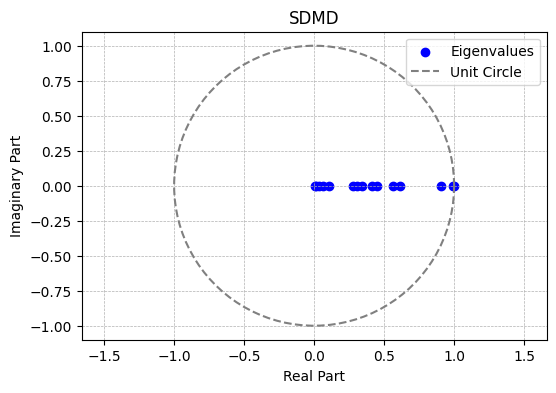

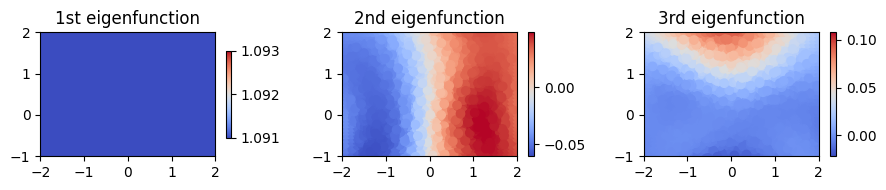

In [7]:
# Assuming 'efuns' is a 2D numpy array with shape (n_samples, n_eigenfunctions)
# and 'X' is a 2D numpy array with shape (n_samples, 2) representing your input data

# Assuming evalues is a numpy array of complex numbers
print(evalues.shape)
print(np.round(evalues, 4))

# Plot eigenvalues on unit circle
real_parts = evalues.real
imag_parts = evalues.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('SDMD')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

# Plot eigenfunctions
fig, axs = plt.subplots(1, 3, figsize=(9, 2))

# Plot for the 1st eigenfunction
# scatter1 = axs[0].scatter(*X.T, c=np.real(efuns)[:, 0], cmap='coolwarm')
scatter1 = axs[0].scatter(*X.T, c=np.real(efuns)[:, 0], cmap='coolwarm', vmin=1.091, vmax=1.093)
axs[0].set_title('1st eigenfunction')
axs[0].set_xlim(-2, 2)
axs[0].set_ylim(-1, 2)
cbar1 = fig.colorbar(scatter1, ax=axs[0], shrink=0.7, aspect=20)

# Plot for the 2nd eigenfunction
scatter2 = axs[1].scatter(*X.T, c=np.real(efuns)[:, 1], cmap='coolwarm')
axs[1].set_title('2nd eigenfunction')
axs[1].set_xlim(-2, 2)
axs[1].set_ylim(-1, 2)
cbar2 = fig.colorbar(scatter2, ax=axs[1])

# Plot for the 3rd eigenfunction
scatter3 = axs[2].scatter(*X.T, c=np.real(efuns)[:, 2], cmap='coolwarm')
axs[2].set_title('3rd eigenfunction')
axs[2].set_xlim(-2, 2)
axs[2].set_ylim(-1, 2)
cbar3 = fig.colorbar(scatter3, ax=axs[2])

# # Plot for the 4th eigenfunction
# scatter4 = axs[3].scatter(*X.T, c=np.real(efuns)[:, 3], cmap='coolwarm')
# axs[3].set_title('4th eigenfunction')
# axs[3].set_xlim(-2, 2)
# axs[3].set_ylim(-1, 2)
# cbar4 = fig.colorbar(scatter4, ax=axs[3])

# fig.suptitle(' SDMD ', fontsize=16)
plt.tight_layout()
plt.show()

In [8]:
del solver, basis_function
torch.cuda.empty_cache()

In [9]:
from solver_gedmd_torch_gpu import KoopmanNNTorch as KoopmanNNTorch_g
from solver_gedmd_torch_gpu import KoopmanSolverTorch as KoopmanSolverTorch_g
#### gEDMD Test ####
checkpoint_file_g= 'well2d_example_ckpt001_g.torch'

basis_function_g = KoopmanNNTorch_g(input_size= 2, layer_sizes=[20, 20], n_psi_train=12).to(device)


solver_g = KoopmanSolverTorch_g(dic=basis_function_g, # Replace 'koopman_nn' by 'dic' if you use the original solver_edmdvar
                       target_dim=np.shape(data_x_train)[-1],
                                                   reg=0.1,  checkpoint_file= checkpoint_file_g, fnn_checkpoint_file= 'example_fnn001.torch', 
                            a_b_file= 'a_b_example_3ple_well.jbl', 
                        generator_batch_size= 16, fnn_batch_size= 32)

solver_g.build_with_generator(
    data_train=data_train,
    data_valid=data_valid,
    epochs=6,
    batch_size=256,
    lr=1e-5,
    log_interval=10,
    lr_decay_factor=.8
    )

solver_g.eig_decomp()  # Do spectral decomposition to generate eigenvalues and eigenvectors

# Results from solver_gedmd
evalues = solver_g.eigenvalues.T
efuns = solver_g.eigenfunctions(X)
#kpm_modes = solver.compute_mode().T
N_dict = np.shape(evalues)[0]
Psi_X = solver_g.get_Psi_X()
Psi_Y = solver_g.get_Psi_Y()


outputs = {
    'efuns': efuns,
    'evalues': evalues,
    # 'kpm_modes': kpm_modes,
    'N_dict': N_dict,
    # 'K': Koopman_matrix_K,
    # 'Psi_X': Psi_X,
    # 'Psi_Y': Psi_Y,
    }


Epoch: 1 	Training Loss: 0.267033 	Validation Loss: 0.125983
Saving model, validation loss improved: 0.125983 < 10000.000000


Epoch: 2 	Training Loss: 0.127569 	Validation Loss: 0.120968
Saving model, validation loss improved: 0.120968 < 0.125983


Epoch: 3 	Training Loss: 0.125059 	Validation Loss: 0.119504
Saving model, validation loss improved: 0.119504 < 0.120968


Epoch: 4 	Training Loss: 0.123653 	Validation Loss: 0.118611
Saving model, validation loss improved: 0.118611 < 0.119504


Epoch: 5 	Training Loss: 0.123071 	Validation Loss: 0.118238
Saving model, validation loss improved: 0.118238 < 0.118611


...

Processing batches:  92%|█████████▏| 494/536 [00:02<00:00, 194.09batch/s]

Processing batches:  96%|█████████▌| 514/536 [00:02<00:00, 193.31batch/s]

Processing batches: 100%|█████████▉| 534/536 [00:02<00:00, 190.49batch/s]

Processing batches: 100%|██████████| 536/536 [00:02<00:00, 197.09batch/s]

Saving best model at epoch 6
EarlyStopping counter: 5 out of 7


(15,)
[1.    +0.j     0.9993+0.j     0.9874+0.j     0.983 +0.j
 0.9723+0.j     0.9564-0.0038j 0.9564+0.0038j 0.8934+0.j
 0.8297+0.j     0.7806+0.j     0.712 +0.j     0.6448+0.j
 0.5349+0.j     0.4095-0.0044j 0.4095+0.0044j]


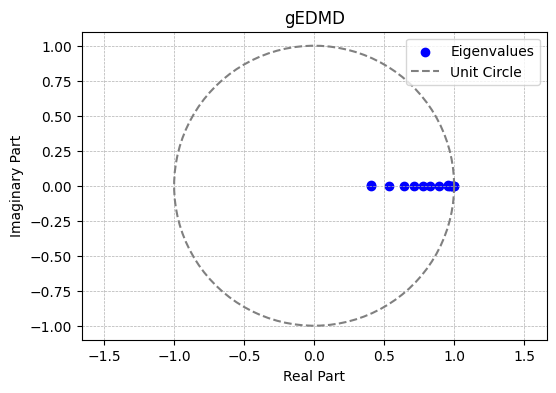

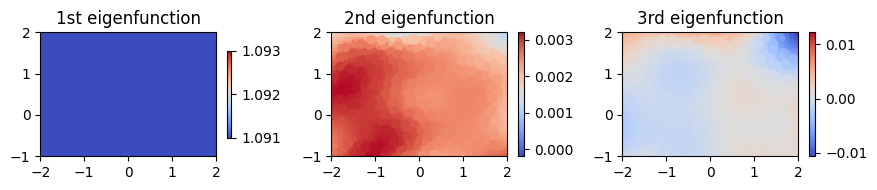

In [10]:
# computing eigenvalues of K from generator eigenvalues using exponetnt
# eigenfunctions are the same for the operator and the generator
evalues_K = np.exp(evalues * lag_time)
sort_idx = evalues_K.real.argsort()[::-1]
evalues_K = evalues_K[sort_idx]
efuns_plot = efuns[:, sort_idx]

# Assuming 'efuns' is a 2D numpy array with shape (n_samples, n_eigenfunctions)
# and 'X' is a 2D numpy array with shape (n_samples, 2) representing your input data
# Assuming evalues is a numpy array of complex numbers

print(evalues_K.shape)
print(np.round(evalues_K, 4))

# Plot eigenvalues on unit circle
real_parts = evalues_K.real
imag_parts = evalues_K.imag

# Create the plot
plt.figure(figsize=(6, 4))
plt.scatter(real_parts, imag_parts, color='blue', label='Eigenvalues')

# Draw a unit circle for reference
theta = np.linspace(0, 2 * np.pi, 100)
plt.plot(np.cos(theta), np.sin(theta), linestyle='--', color='grey', label='Unit Circle')

plt.title('gEDMD')
plt.xlabel('Real Part')
plt.ylabel('Imaginary Part')
plt.axis('equal')  # Ensure the aspect ratio is equal to make the unit circle round
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.show()

# Plot eigenfunctions
fig, axs = plt.subplots(1, 3, figsize=(9, 2))

# Plot for the 1st eigenfunction
# scatter1 = axs[0].scatter(*X.T, c=np.real(efuns_plot)[:, 0], cmap='coolwarm')
scatter1 = axs[0].scatter(*X.T, c=np.real(efuns_plot)[:, 0], cmap='coolwarm', vmin=1.091, vmax=1.093)
axs[0].set_title('1st eigenfunction')
axs[0].set_xlim(-2, 2)
axs[0].set_ylim(-1, 2)
cbar1 = fig.colorbar(scatter1, ax=axs[0], shrink=0.7, aspect=20)

# Plot for the 2nd eigenfunction
scatter2 = axs[1].scatter(*X.T, c=np.real(efuns_plot)[:, 1], cmap='coolwarm')
axs[1].set_title('2nd eigenfunction')
axs[1].set_xlim(-2, 2)
axs[1].set_ylim(-1, 2)
cbar2 = fig.colorbar(scatter2, ax=axs[1])

# Plot for the 3rd eigenfunction
scatter3 = axs[2].scatter(*X.T, c=np.real(efuns_plot)[:, 2], cmap='coolwarm')
axs[2].set_title('3rd eigenfunction')
axs[2].set_xlim(-2, 2)
axs[2].set_ylim(-1, 2)
cbar3 = fig.colorbar(scatter3, ax=axs[2])

# # Plot for the 4th eigenfunction
# scatter4 = axs[3].scatter(*X.T, c=np.real(efuns_plot)[:, 3], cmap='coolwarm')
# axs[3].set_title('4th eigenfunction')
# axs[3].set_xlim(-2, 2)
# axs[3].set_ylim(-1, 2)
# cbar4 = fig.colorbar(scatter4, ax=axs[3])

# fig.suptitle(' gEDMD ', fontsize=16)
plt.tight_layout()
plt.show()
